# STAC Catalogue

Link Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ftl-brazil-2026/ebook/blob/main/fundamentals_gis_rs/week2/RS-STAC.ipynb)


Nós vimos que é facil entrar em um provedor, pesquisar uma data e encontrar as images que queremos. Porém baixar tudo na mão parece ser extremamente trabalhoso, demandando muito tempo para prosseguir. Dessa forma, a comunidade engajada do mundo geoespacial criou o STAC (Spatial Temporal Asset Catalogue), que basicamente reune todos os provedores e dados em um sistema organizado que te permite buscar, localizar e baixar as images de sua preferência. 
Primeiramente vamos nos familiarizar um pouco com o STAC antes de prosseguirmos com operações mais avançadas de sensoriamento remoto. 

In [1]:
from pystac_client import Client

In [2]:
Client?

Precisamos entao encontrar a nossa API para depois conseguir baixar os dados. Assim, o próprio site da STAC favorece uma lista de API
[STAC-API-catalogo](https://stacindex.org/catalogs?type=api)

In [3]:
cbers_inpe = "https://data.inpe.br/bdc/stac/v1/"

In [4]:
client = Client.open(cbers_inpe)

In [5]:
# vamos listar todas as colecoes
for collection in client.get_collections():
    print(collection)

<CollectionClient id=GOES19-L2-CMI-1>
<CollectionClient id=S2_L2A-1>
<CollectionClient id=AMZ1-WFI-L2-DN-1>
<CollectionClient id=mosaic-cbers4a-paraiba-3m-1>
<CollectionClient id=mosaic-landsat-sp-6m-1>
<CollectionClient id=mosaic-s2-paraiba-3m-1>
<CollectionClient id=mosaic-s2-yanomami_territory-6m-1>
<CollectionClient id=modisa-ocsmart-rrs-monthly-1>
<CollectionClient id=landsat-2>
<CollectionClient id=s3-olci-rrs-water-1>
<CollectionClient id=AMZ1-WFI-L4-DN-1>
<CollectionClient id=s3-olci-pc-tiete-1>
<CollectionClient id=mod13q1-6.1>
<CollectionClient id=sentinel-1-grd-bundle-1>
<CollectionClient id=s2_msi_mq_wqp-1>
<CollectionClient id=sentinel-1-rtc-1>
<CollectionClient id=sentinel-3-olci-l1-bundle-1>
<CollectionClient id=CB4-MUX-L2-DN-1>
<CollectionClient id=s2_msi_mq_rrs-1>
<CollectionClient id=S2-16D-2>
<CollectionClient id=GOES-GL-DSWRF-Daily-1>
<CollectionClient id=mosaic-landsat-amazon-3m-1>
<CollectionClient id=CBERS4-WFI-16D-2>
<CollectionClient id=mosaic-s2-amazon-3m-1>
<

In [6]:
# vamos ver a metadata
collection = client.get_collection('CB4-MUX-L4-SR-1')

In [7]:
collection

<CollectionClient id=CB4-MUX-L4-SR-1>

### Encontre a sua bbox por aqui:
[bbox finder](https://rodostoteknoloji.com/online-tools/bbox-tool-en.html)

In [8]:
search = client.search(
    max_items=10,
    collections=["sentinel-2-c1-l2a"],
    bbox=[-45.963435, -11.891593, -45.423607, -11.525831]
)

In [9]:
item_search = client.search(bbox=[-45.963435, -11.891593, -45.423607, -11.525831],
                             datetime='2024-08-01/2025-07-31',
                             collections=['CB4-MUX-L4-SR-1'],
                             query={
                                 "eo:cloud_cover": {"lt": 15}
                                 })

## voce pode passar mais filtros as query como
# query={
#         "tileId": {"in": ["22JHT", "22JGT", "22KHU", "22KGU"]}
# }
## nesse caso selecionando todos os tiles
item_search

Esse método retorna uma representação `ItemSearch` a qual possue métodos acessíveis para identificar os resultados

In [10]:
item_search.matched()

19

In [11]:
for item in item_search.items():
    print(item)

<Item id=CBERS_4_MUX_20250722_156_113_L4>
<Item id=CBERS_4_MUX_20250719_157_113_L4>
<Item id=CBERS_4_MUX_20250626_156_113_L4>
<Item id=CBERS_4_MUX_20250623_157_113_L4>
<Item id=CBERS_4_MUX_20250531_156_113_L4>
<Item id=CBERS_4_MUX_20250528_157_113_L4>
<Item id=CBERS_4_MUX_20250505_156_113_L4>
<Item id=CBERS_4_MUX_20250409_156_113_L4>
<Item id=CBERS_4_MUX_20250314_156_113_L4>
<Item id=CBERS_4_MUX_20250121_156_113_L4>


<Item id=CBERS_4_MUX_20241223_157_113_L4>
<Item id=CBERS_4_MUX_20241130_156_113_L4>
<Item id=CBERS_4_MUX_20241101_157_113_L4>
<Item id=CBERS_4_MUX_20241009_156_113_L4>
<Item id=CBERS_4_MUX_20241006_157_113_L4>
<Item id=CBERS_4_MUX_20240913_156_113_L4>
<Item id=CBERS_4_MUX_20240910_157_113_L4>
<Item id=CBERS_4_MUX_20240818_156_113_L4>
<Item id=CBERS_4_MUX_20240815_157_113_L4>


Isso é tudo? Claro que não, também podemos filtrar através do nosso querido `geopandas`

Toma essa pedrada aqui

In [12]:
import geobr

In [13]:
muni = geobr.read_municipality(year=2020)
muni = muni.loc[muni['abbrev_state']=='PA']

In [14]:
# convert to WGS84 (padrao internacional)
acara = muni.to_crs(4326).iloc[3]

In [15]:
geom = acara.geometry

bounds = geom.bounds

print(f"Geometria: {geom}")
print()
print(f"Tipo da geometria: {geom.geom_type}")
print()
print(f"Bounds: {bounds}")

Geometria: POLYGON ((-50.50552749999999 0.18421312, -50.487641394 0.182131646, -50.47088226999999 0.177517622, -50.453262471 0.168380503, -50.432880081 0.149561829, -50.412970485 0.11246927, -50.39569862999999 0.050498172, -50.392408435 0.043802715, -50.377884294 0.022813954, -50.33181063899999 -0.013135121, -50.303169569 -0.058106244, -50.298803919 -0.0682877, -50.29750065799999 -0.076907141, -50.29866601199999 -0.101589071, -50.195977641 -0.213524257, -50.107219092 -0.470861646, -50.114524226 -0.4647672029999998, -50.233640676 -0.312785947, -50.23793479799999 -0.314432649, -50.24891409999999 -0.328941307, -50.248903115 -0.331782522, -50.26709537499999 -0.343060697, -50.268934353999995 -0.347090542, -50.26434494699999 -0.349092106, -50.26432067199999 -0.3536532110000001, -50.272549680000004 -0.3563823700000001, -50.270107392 -0.362346172, -50.271754099 -0.3664660499999999, -50.27124171199999 -0.369450066, -50.272674329999994 -0.370605038, -50.270769655 -0.374336869, -50.27273425599999

In [16]:
import folium
from shapely.geometry import box

bounds_polygon = box(*bounds)

centro_lat = (bounds[1] + bounds[3]) / 2
centro_lon = (bounds[0] + bounds[2]) / 2

m = folium.Map(location=[centro_lat, centro_lon], zoom_start=15)

folium.GeoJson(
    geom,
    name="Acara",
    style_function=lambda x: {
        'fillColor': 'green',
        'color': 'darkgreen',
        'weight': 2,
        'fillOpacity': 0.5
    }
).add_to(m)

folium.GeoJson(
    bounds_polygon.__geo_interface__,
    name="Bounds",
    style_function=lambda x: {
        'fillColor': 'none',
        'color': 'blue',
        'weight': 3,
        'fillOpacity': 0
    }
).add_to(m)

m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])
m

In [17]:

item_search = Client.open('https://data.inpe.br/bdc/stac/v1/').search(intersects=geom,
                             datetime='2024-08-01/2025-07-31',
                             collections=['CB4-MUX-L4-SR-1'],
                             query={"eo:cloud_cover": {"lt": 15}})
print(item_search.matched())

7


In [18]:
item_list = list(item_search.items())
item_list

[<Item id=CBERS_4_MUX_20250727_163_101_L4>,
 <Item id=CBERS_4_MUX_20250724_164_101_L4>,
 <Item id=CBERS_4_MUX_20250628_164_101_L4>,
 <Item id=CBERS_4_MUX_20241011_164_100_L4>,
 <Item id=CBERS_4_MUX_20240915_164_100_L4>,
 <Item id=CBERS_4_MUX_20240915_164_101_L4>,
 <Item id=CBERS_4_MUX_20240817_165_100_L4>]

### Assets

Assets é onde estão guardado as metadatas, thumbnails, imagens e bandas.


In [19]:
item_n = 6
print(item_list[item_n])
item = item_list[item_n]

<Item id=CBERS_4_MUX_20240817_165_100_L4>


In [20]:
item.assets

{'BAND5': <Asset href=https://data.inpe.br/bdc/data/CB4-MUX-L4-SR/2024_08/CBERS_4_MUX_DRD_2024_08_17.13_26_30_CB11/165_100_0/4_BC_UTM_WGS84/CBERS_4_MUX_20240817_165_100_L4_BAND5_GRID_SURFACE.tif>,
 'BAND6': <Asset href=https://data.inpe.br/bdc/data/CB4-MUX-L4-SR/2024_08/CBERS_4_MUX_DRD_2024_08_17.13_26_30_CB11/165_100_0/4_BC_UTM_WGS84/CBERS_4_MUX_20240817_165_100_L4_BAND6_GRID_SURFACE.tif>,
 'BAND7': <Asset href=https://data.inpe.br/bdc/data/CB4-MUX-L4-SR/2024_08/CBERS_4_MUX_DRD_2024_08_17.13_26_30_CB11/165_100_0/4_BC_UTM_WGS84/CBERS_4_MUX_20240817_165_100_L4_BAND7_GRID_SURFACE.tif>,
 'BAND8': <Asset href=https://data.inpe.br/bdc/data/CB4-MUX-L4-SR/2024_08/CBERS_4_MUX_DRD_2024_08_17.13_26_30_CB11/165_100_0/4_BC_UTM_WGS84/CBERS_4_MUX_20240817_165_100_L4_BAND8_GRID_SURFACE.tif>,
 'CMASK': <Asset href=https://data.inpe.br/bdc/data/CB4-MUX-L4-SR/2024_08/CBERS_4_MUX_DRD_2024_08_17.13_26_30_CB11/165_100_0/4_BC_UTM_WGS84/CBERS_4_MUX_20240817_165_100_L4_CMASK_GRID_SURFACE.tif>,
 'thumbnail': <

In [21]:
for k in item.assets.keys():
    print(k)

BAND5
BAND6
BAND7
BAND8
CMASK
thumbnail


# Rasterio e Numpy para acessar as images de satélite

In [22]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt 

### Monitorando o uso de RAM

Imagens de satélite em resolução completa ocupam bastante memória (uma única banda dessa cena tem quase 51 milhões de pixels!). Se seu computador tem 4GB de RAM, é fácil travar o Jupyter sem perceber. Vamos criar uma função com `psutil` para acompanhar o consumo de memória RAM ao longo do notebook.

In [23]:
import psutil

def check_memory(label: str = "", warn_threshold: float = 85.0) -> None:
    """Imprime o uso atual de RAM e alerta se estiver perto do limite da máquina."""
    mem = psutil.virtual_memory()
    used_gb = mem.used / (1024 ** 3)
    total_gb = mem.total / (1024 ** 3)
    available_gb = mem.available / (1024 ** 3)

    prefix = f"[RAM] {label}: " if label else "[RAM] "
    print(f"{prefix}{used_gb:.2f} GB usados de {total_gb:.2f} GB ({mem.percent:.1f}%) | disponível: {available_gb:.2f} GB")

    if mem.percent >= warn_threshold:
        print(f"ATENÇÃO: uso de RAM acima de {warn_threshold:.0f}%! Considere reiniciar o kernel, "
              "fechar outros programas, ou usar leitura por janelas (Window), como veremos mais adiante.")

check_memory("linha de base")

[RAM] linha de base: 7.38 GB usados de 32.00 GB (69.2%) | disponível: 9.86 GB


In [24]:
assets = item.assets
with rasterio.open(assets['BAND5'].href) as blue_ds:
    blue = blue_ds.read(1)

In [25]:
blue.shape

(6945, 7281)

In [26]:
blue.mean()

np.float64(-2712.703948173639)

In [27]:
with rasterio.open(assets['BAND6'].href) as green_ds:
    green = green_ds.read(1)
with rasterio.open(assets['BAND7'].href) as blue_ds:
    red = blue_ds.read(1)

In [28]:
check_memory("depois de carregar 3 bandas em resolução total")

[RAM] depois de carregar 3 bandas em resolução total: 8.33 GB usados de 32.00 GB (71.6%) | disponível: 9.08 GB


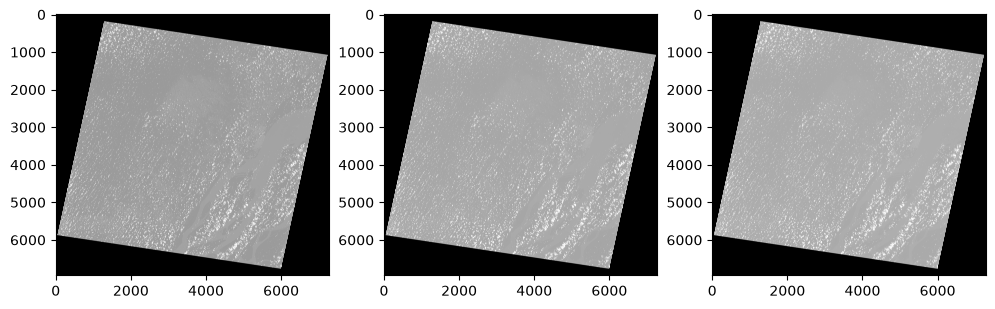

In [29]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(12, 4))
ax1.imshow(red, cmap='gray')
ax2.imshow(green, cmap='gray')
ax3.imshow(blue, cmap='gray')

vamos criar uma composição agora com as 3 bandas: RGB

In [30]:
def normalize(array, brightness_factor=1):
    """Normalizes numpy arrays with optional brightness adjustment"""
    array_min, array_max = array.min(), array.max()
    normalized = (array - array_min) / (array_max - array_min)
    return np.clip(normalized * brightness_factor, 0, 1)

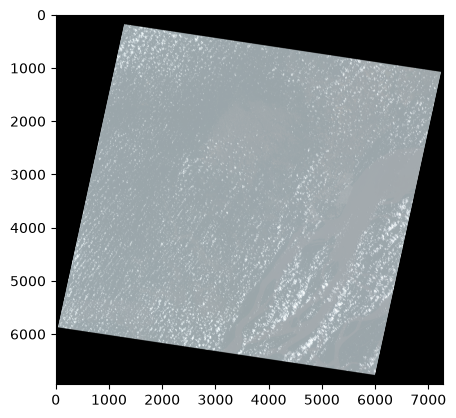

In [31]:
brightness_factor = 1
rgb = np.dstack((
    normalize(red, brightness_factor), 
    normalize(green, brightness_factor), 
    normalize(blue, brightness_factor))
)
plt.imshow(rgb)

In [32]:
check_memory("depois de criar a composição RGB (arrays float64)")

[RAM] depois de criar a composição RGB (arrays float64): 8.95 GB usados de 32.00 GB (78.5%) | disponível: 6.88 GB


# que tal uma composição de falsa cor? 

Lembrando que é NIR, G, B:

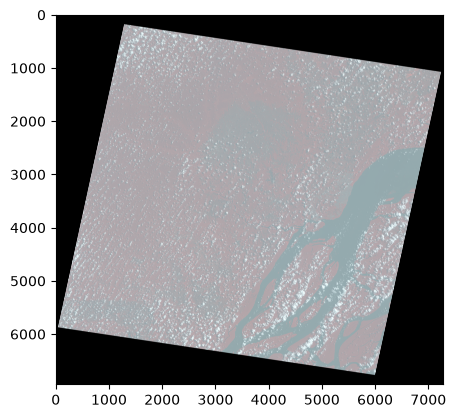

In [33]:
with rasterio.open(assets['BAND8'].href) as nir_ds:
    nir = nir_ds.read(1)

brightness_factor = 1
rgb = np.dstack((
    normalize(nir, brightness_factor), 
    normalize(green, brightness_factor), 
    normalize(blue, brightness_factor))
)
plt.imshow(rgb)

### Rasterio - Window

Ao inves de acessar a imagem inteira (7000x7000 pixels), a gente pode utilizar uma função para só acessar um pedacinho dessa imagem, a nossa área de interesse 

In [34]:
from rasterio.windows import Window

In [35]:
def read(uri: str, 
         window: Window,
        masked: bool = True):
    """Read raster window as numpy.ma.masked_array."""
    with rasterio.open(uri) as ds:
        return ds.read(1, window=window, masked=masked)

In [36]:
red = read(assets['BAND7'].href, window=Window(0, 0, 500, 500)) # Window(col_off, row_off, width, height)
green = read(assets['BAND6'].href, window=Window(0, 0, 500, 500))
blue = read(assets['BAND5'].href, window=Window(0, 0, 500, 500))

In [37]:
check_memory("depois de ler só uma janela (window) de 500x500 pixels")
# compare esse valor com o de "depois de carregar 3 bandas em resolução total" acima:
# ler por janelas é a estratégia recomendada se sua máquina tem pouca RAM (ex: 4GB)

[RAM] depois de ler só uma janela (window) de 500x500 pixels: 7.06 GB usados de 32.00 GB (76.2%) | disponível: 7.62 GB


ao invés de passar os valores dos posição de pixel, você poderia passar somente as coordenadas

In [38]:
from rasterio.windows import from_bounds

In [39]:
from pyproj import Transformer

def transform_bounds(bounds, 
                     from_crs='EPSG:4326', 
                     to_crs=None):
    transformer = Transformer.from_crs(from_crs, to_crs, always_xy=True)
    
    minx, miny = transformer.transform(bounds[0], bounds[1])
    maxx, maxy = transformer.transform(bounds[2], bounds[3])
    
    return (minx, miny, maxx, maxy)

In [40]:
green

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=-9999,
  dtype=int16)

In [41]:
bounds

(-51.432479184, -0.723834631, -50.107219092, 0.249357407)

In [42]:
with rasterio.open(assets['BAND5'].href) as src:
    reprojected_bounds = transform_bounds(bounds, 'EPSG:4326', src.crs)
    window = from_bounds(
        reprojected_bounds[0],  # left
        reprojected_bounds[1],  # bottom  
        reprojected_bounds[2],  # right
        reprojected_bounds[3],  # top
        src.transform
    )
    window = window.round_offsets().round_lengths()
    
    blue = read(assets['BAND5'].href, window=window, masked=True)
    green = read(assets['BAND6'].href, window=window, masked=True)
    red = read(assets['BAND7'].href, window=window, masked=True)
print(red.shape)

(4781, 3878)


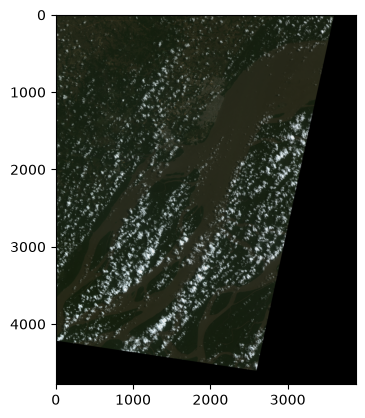

In [43]:
brightness_factor = 1
rgb = np.dstack((
    normalize(red, brightness_factor), 
    normalize(green, brightness_factor), 
    normalize(blue, brightness_factor))
)
plt.imshow(rgb)

# Como baixar as imagens em seu computador

O procedimento é o mesmo de tudos que vimos até agora, a única diferença é que vamos baixar cada asset em nossa máquina.

Na próxima célula, deixo uma função que permite vocês baixarem

Uma imagem completa pode ter em 2 a 3 GB

In [44]:
import os
from urllib.parse import urlparse

import requests
from pystac import Asset
from tqdm import tqdm

# def download(asset: Asset, directory: str = None, chunk_size: int = 1024 * 16, **request_options) -> str:
#     """Smart download STAC Item asset.

#     This method uses a checksum validation and a progress bar to monitor download status.
#     """
#     if directory is None:
#         directory = ''

#     response = requests.get(asset.href, stream=True, **request_options)
#     output_file = os.path.join(directory, urlparse(asset.href)[2].split('/')[-1])
#     os.makedirs(directory, exist_ok=True)
#     total_bytes = int(response.headers.get('content-length', 0))
#     with tqdm.wrapattr(open(output_file, 'wb'), 'write', miniters=1, total=total_bytes, desc=os.path.basename(output_file)) as fout:
#         for chunk in response.iter_content(chunk_size=chunk_size):
#             fout.write(chunk)

In [45]:
# download(assets['BAND5'], 'img')

In [46]:
# para baixar todas as bandas de uma imagem, entao:
# for asset in assets.values():
#     download(asset, 'images')

# Painel Interativo

Vamos fechar essa aula com um painel interativo, aquele painel que você vê por aí no LinkedIn ou como Google Earth Engine webgis. Vamos montar o mesmo efeito com o [`leafmap`](https://leafmap.org/), usando o seu backend baseado em `folium` (`leafmap.foliumap`).

Fluxo de ponta a ponta:
1. Escolher uma área em qualquer lugar do Brasil;
2. Buscar no STAC duas cenas da mesma área, em anos diferentes;
3. Ler as bandas por janela (bbox) e montar duas composições RGB;
4. Salvar cada composição como um GeoTIFF local (com a georreferência da janela);
5. Servir os dois GeoTIFFs com `leafmap.foliumap.Map().split_map(...)`, que já vem com o controle de swipe.

Vamos usar como exemplo o **avanço do desmatamento na Amazônia**, na região de Novo Progresso (PA), ao longo da BR-163 — uma área com um recorte antes/depois bem marcante.

In [144]:
import os

import leafmap.foliumap as leafmap
from rasterio.windows import transform as window_transform

## 1. Buscando as cenas para mesma área

O `bbox` abaixo pode ser trocado por qualquer área do Brasil (use o [bbox finder](https://rodostoteknoloji.com/online-tools/bbox-tool-en.html) lá em cima). Vamos buscar cenas CBERS-4/MUX com poucas nuvens em dois anos bem separados, para o desmatamento ficar evidente.

In [145]:
# Novo Progresso (PA), fronteira de desmatamento ao longo da BR-163
bbox = [-55.30, -8.35, -55.05, -8.15]

client = Client.open("https://data.inpe.br/bdc/stac/v1/")

for ano in ["2017-01-01/2017-12-31", "2023-01-01/2023-12-31"]:
    s = client.search(collections=["CB4-MUX-L4-SR-1"], 
                      bbox=bbox, 
                      datetime=ano,
                       query={"eo:cloud_cover": {"lt": 15}}
                       )
    print(ano, "- imagens encontradas:", s.matched())
    for it in s.items():
        print(" ", it.id, "- nuvens:", round(it.properties["eo:cloud_cover"], 1), "%")
    print()

2017-01-01/2017-12-31 - imagens encontradas: 10
  CBERS_4_MUX_20171103_167_109_L4 - nuvens: 13.1 %
  CBERS_4_MUX_20171103_167_110_L4 - nuvens: 10.5 %
  CBERS_4_MUX_20170912_167_109_L4 - nuvens: 1.0 %
  CBERS_4_MUX_20170912_167_110_L4 - nuvens: 0.4 %
  CBERS_4_MUX_20170626_167_109_L4 - nuvens: 0.0 %
  CBERS_4_MUX_20170626_167_110_L4 - nuvens: 0.0 %
  CBERS_4_MUX_20170505_167_109_L4 - nuvens: 1.7 %
  CBERS_4_MUX_20170505_167_110_L4 - nuvens: 4.1 %
  CBERS_4_MUX_20170409_167_109_L4 - nuvens: 4.1 %
  CBERS_4_MUX_20170409_167_110_L4 - nuvens: 13.5 %

2023-01-01/2023-12-31 - imagens encontradas: 13
  CBERS_4_MUX_20231027_168_109_L4 - nuvens: 10.4 %
  CBERS_4_MUX_20231001_168_109_L4 - nuvens: 2.2 %
  CBERS_4_MUX_20230908_167_109_L4 - nuvens: 6.7 %
  CBERS_4_MUX_20230905_168_109_L4 - nuvens: 2.8 %
  CBERS_4_MUX_20230813_167_109_L4 - nuvens: 0.8 %
  CBERS_4_MUX_20230813_167_110_L4 - nuvens: 0.7 %
  CBERS_4_MUX_20230810_168_110_L4 - nuvens: 1.9 %
  CBERS_4_MUX_20230718_167_109_L4 - nuvens: 0.0 %

Vamos escolher duas cenas do **mesmo tile** (167_109), uma de cada ano, ambas com 0% de nuvens.

In [148]:
item_2017 = list(client.search(collections=["CB4-MUX-L4-SR-1"], 
                               ids=["CBERS_4_MUX_20170626_167_109_L4"]).items())[0]
item_2023 = list(client.search(collections=["CB4-MUX-L4-SR-1"], 
                               ids=["CBERS_4_MUX_20230718_167_109_L4"]).items())[0]

print(item_2017)
print(item_2023)

<Item id=CBERS_4_MUX_20170626_167_109_L4>
<Item id=CBERS_4_MUX_20230718_167_109_L4>


### 2. Lendo por bbox e montando as composições RGB

Vamos reaproveitar o `transform_bounds` e o `from_bounds` que já vimos, e o `check_memory` da aula, para ler só a nossa área de interesse em cada cena.

In [149]:
def read_bbox(href: str, bbox: list, masked: bool = True):
    """Lê a janela do raster correspondente ao bbox (em EPSG:4326), com a georreferência da janela."""
    with rasterio.open(href) as src:
        reprojected_bounds = transform_bounds(bbox, "EPSG:4326", src.crs)
        window = from_bounds(*reprojected_bounds, src.transform).round_offsets().round_lengths()
        data = read(href, window=window, masked=masked)
        return data, window_transform(window, src.transform), src.crs


def read_rgb(item, bbox):
    assets = item.assets
    red, transform, crs = read_bbox(assets["BAND7"].href, bbox)
    green, _, _ = read_bbox(assets["BAND6"].href, bbox)
    blue, _, _ = read_bbox(assets["BAND5"].href, bbox)
    return red.astype("float64"), green.astype("float64"), blue.astype("float64"), transform, crs


red_2017, green_2017, blue_2017, transform_2017, crs_2017 = read_rgb(item_2017, bbox)
check_memory("depois de ler a cena de 2017")

red_2023, green_2023, blue_2023, transform_2023, crs_2023 = read_rgb(item_2023, bbox)
check_memory("depois de ler a cena de 2023")

print("shape:", red_2017.shape)

[RAM] depois de ler a cena de 2017: 8.77 GB usados de 32.00 GB (70.7%) | disponível: 9.39 GB
[RAM] depois de ler a cena de 2023: 8.83 GB usados de 32.00 GB (70.8%) | disponível: 9.35 GB
shape: (1100, 1382)


Para essa cena vamos usar um contraste por percentil ao invés de min/max que usamos antes. Esse constrate por percentil evitar de a sensibilidade de pixels ficarem muito claros ou muito escuros..

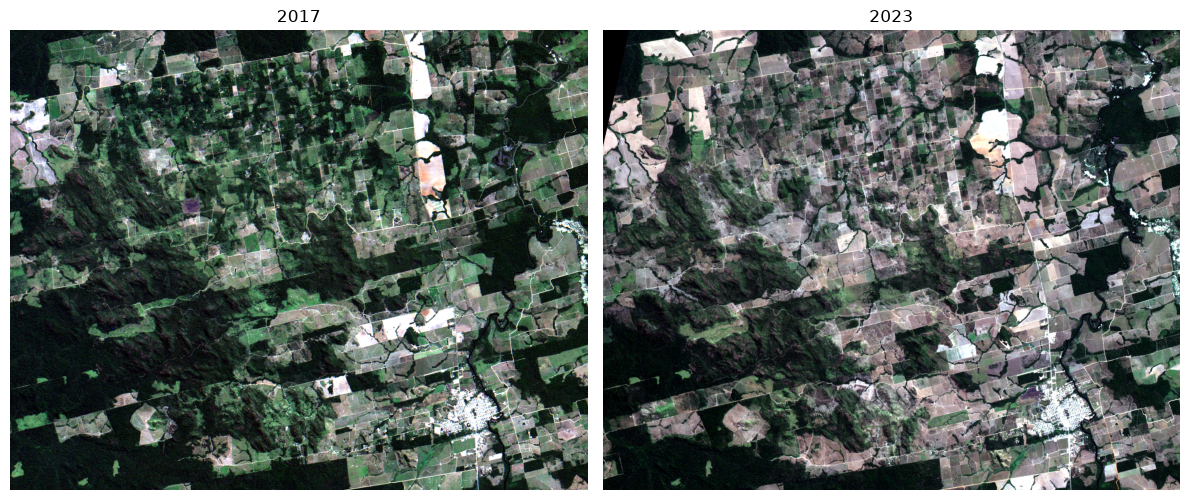

In [150]:
def stretch(array, 
            low_pct=2, 
            high_pct=98):
    """Normaliza um array usando contraste por percentil."""
    data = np.ma.filled(array, np.nan)
    valid = data[np.isfinite(data)]
    p_lo, p_hi = np.percentile(valid, [low_pct, high_pct])
    return np.clip((array - p_lo) / (p_hi - p_lo), 0, 1)

# essa funcao converte em int 8 bits of quantization
def make_rgb_uint8(red, green, blue):
    rgb = np.dstack((stretch(red), stretch(green), stretch(blue)))
    return (np.ma.filled(rgb, 0) * 255).astype("uint8")


rgb_2017 = make_rgb_uint8(red_2017, green_2017, blue_2017)
rgb_2023 = make_rgb_uint8(red_2023, green_2023, blue_2023)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(rgb_2017)
ax1.set_title("2017")
ax1.axis("off")
ax2.imshow(rgb_2023)
ax2.set_title("2023")
ax2.axis("off")
plt.tight_layout()
plt.show()

## 3. Salvando como GeoTIFF

Aqui vamos salvar cada composição como um **GeoTIFF** em disco, usando a transformação e o CRS da própria janela que lemos. Esse raster processado pode ser facilmente aberto no QGIS.

In [151]:
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)


def write_rgb_geotiff(red, green, blue, transform, crs, out_path):
    """Salva uma composição RGB (uint8) como GeoTIFF local."""
    rgb_uint8 = make_rgb_uint8(red, green, blue)  # (linhas, colunas, bandas)
    rgb_uint8 = np.transpose(rgb_uint8, (2, 0, 1))  # rasterio espera (bandas, linhas, colunas)
    with rasterio.open(
        out_path, "w",
        driver="GTiff",
        height=rgb_uint8.shape[1],
        width=rgb_uint8.shape[2],
        count=3,
        dtype="uint8",
        crs=crs,
        transform=transform,
    ) as dst:
        dst.write(rgb_uint8)
    return out_path


tif_2017 = write_rgb_geotiff(red_2017, green_2017, blue_2017, transform_2017, crs_2017,
                              os.path.join(output_dir, "novo_progresso_2017.tif"))
tif_2023 = write_rgb_geotiff(red_2023, green_2023, blue_2023, transform_2023, crs_2023,
                              os.path.join(output_dir, "novo_progresso_2023.tif"))

print(tif_2017)
print(tif_2023)

outputs/novo_progresso_2017.tif
outputs/novo_progresso_2023.tif


## 4. Montando o painel com leafmap

`leafmap.foliumap.Map` é uma subclasse de `folium.Map`, então ela renderiza como HTML puro. O `split_map` recebe os dois caminhos de arquivo e cuida de servir cada GeoTIFF como tiles (via `localtileserver`) e de montar o controle de swipe.

In [152]:
m = leafmap.Map()
m.split_map(
    left_layer=tif_2017,
    right_layer=tif_2023,
    left_label="2017",
    right_label="2023",
)
m



> **Nota:** diferente da tentativa anterior com uma imagem estática, agora as duas camadas são servidas como tiles de verdade pelo `localtileserver` (um servidor local que roda junto com o kernel), então elas não pixelam ao aproximar o zoom. Isso também significa que o mapa só funciona enquanto o kernel do notebook estiver rodando na sua máquina.

# Referências

- [Brazil Data Cube - Python](https://github.com/brazil-data-cube/code-gallery/blob/master/jupyter/Python/stac/stac-and-geometries.ipynb)
- E-book - [BDC](https://brazil-data-cube.github.io/)
- Apostila INPE - [INPE](https://www3.inpe.br/unidades/cep/atividadescep/educasere/apostila.htm)